# 07. Severstal Stage 1: 정상 vs 비정상 ML 이진 분류

## 개요
- **목표**: Severstal 철강 패치에서 정상/비정상을 전통 ML로 분류
- **데이터**: 정상 500 + 비정상 500 = 1,000 패치 (256×256 → 200×200)
- **패치 전략**: v6.0 오버랩 패치 (stride=128, 총 150,816장에서 샘플링)
- **특징**: HOG + LBP + Pixel Stats + Edge + Contour
- **모델**: SVM, RandomForest, KNN, MLP, XGBoost, LightGBM, VotingEnsemble

In [1]:
import os, sys, numpy as np, time
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

sys.path.insert(0, os.path.abspath('..'))

from utils.severstal_preprocessor import PatchDataLoader
from utils.severstal_loader import SeverstalDataLoader, CLASS_NAMES_KR, CLASS_ABBR
from features.feature_pipeline import FeaturePipeline

print("모듈 로드 완료")

모듈 로드 완료


## 1. 데이터 로드 및 EDA

In [2]:
# 패치 통계 확인
patch_dir = os.path.join('..', 'data', 'severstal_patches')
patch_loader = PatchDataLoader(patch_dir)
patch_loader.print_stats()


Severstal 크롭 패치 — 통계
정상 패치: 120,583장
ClassId 1 (점상 결함 (PS)): 2,638장
ClassId 2 (선형 긁힘 (LS)): 457장
ClassId 3 (표면 변색 (SS)): 23,408장
ClassId 4 (압연 압흔 (RD)): 3,730장

총 비정상 패치: 30,233장
총 패치: 150,816장


In [3]:
# 이진 분류 데이터 로드 (균형: 500/class → 노트북 실행 시간 최적화)
images, labels = patch_loader.load_binary(
    max_per_class=500, resize=(200, 200), grayscale=True
)
print(f'로드 완료: {len(images)}장')
print(f'  정상: {(labels==0).sum()}장')
print(f'  비정상: {(labels==1).sum()}장')
print(f'  이미지 shape: {images[0].shape}')

로드 완료: 1000장
  정상: 500장
  비정상: 500장
  이미지 shape: (200, 200)


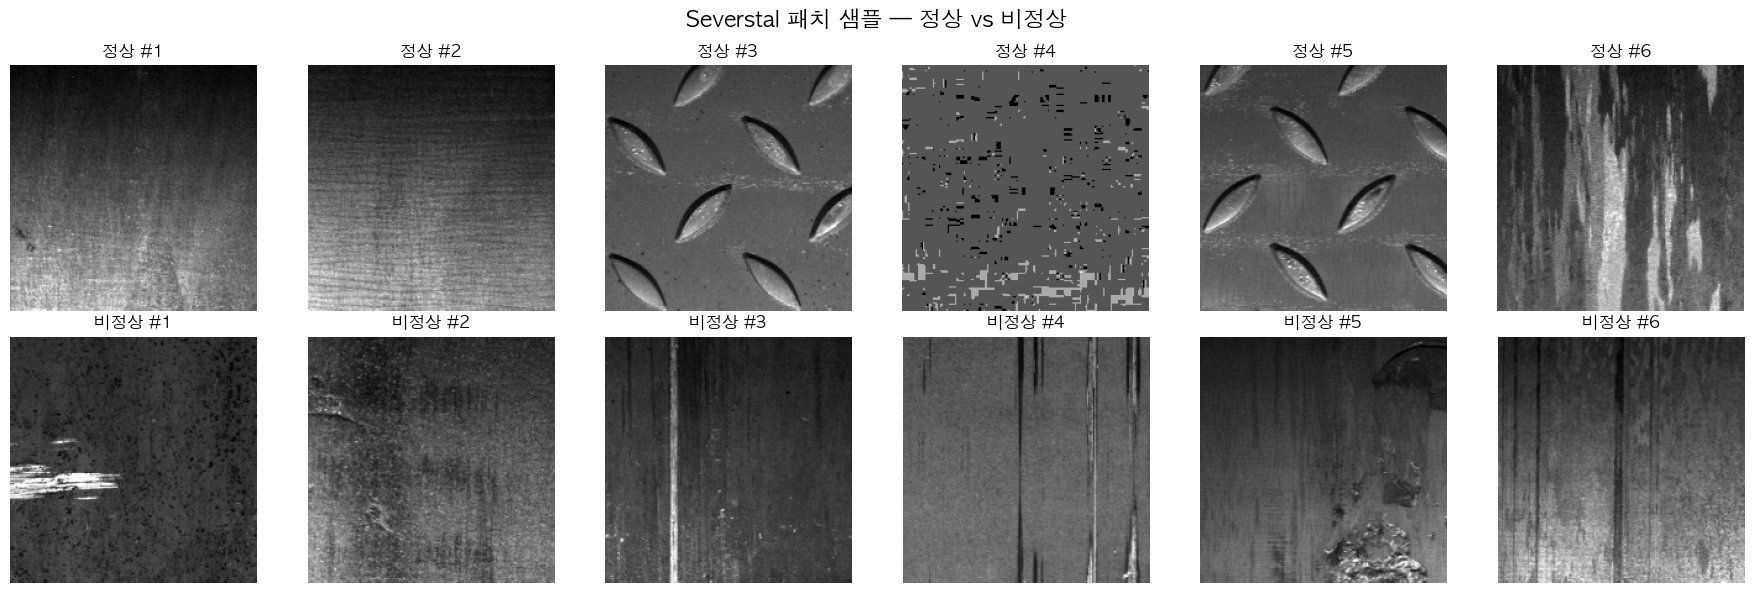

In [4]:
# 샘플 시각화: 정상 vs 비정상
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle('Severstal 패치 샘플 — 정상 vs 비정상', fontsize=16, fontweight='bold')

normal_idx = np.where(labels == 0)[0]
defect_idx = np.where(labels == 1)[0]
step_n = max(1, len(normal_idx) // 6)
step_d = max(1, len(defect_idx) // 6)

for i in range(6):
    # 정상
    axes[0, i].imshow(images[normal_idx[i * step_n]], cmap='gray')
    axes[0, i].set_title(f'정상 #{i+1}')
    axes[0, i].axis('off')
    # 비정상
    axes[1, i].imshow(images[defect_idx[i * step_d]], cmap='gray')
    axes[1, i].set_title(f'비정상 #{i+1}')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('정상', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('비정상', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/severstal/07_binary_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 특징 추출

In [5]:
t0 = time.time()
pipeline = FeaturePipeline()
X, _ = pipeline.extract_batch(images)
elapsed = time.time() - t0
print(f'특징 벡터: {X.shape}')
print(f'소요시간: {elapsed:.1f}s ({elapsed/len(images)*1000:.1f}ms/장)')
print(f'특징 차원: {X.shape[1]}D')

  특징 추출: 200/1000 (20%)


  특징 추출: 400/1000 (40%)


  특징 추출: 600/1000 (60%)


  특징 추출: 800/1000 (80%)


  특징 추출: 1000/1000 (100%)
특징 벡터: (1000, 20916)
소요시간: 17.4s (17.4ms/장)
특징 차원: 20916D


## 3. 7종 ML 모델 학습 및 평가

In [6]:
from models.train_binary import run_binary_experiment

save_dir = os.path.join('..', 'outputs', 'models_severstal', 'binary_ml')
results, X_test, y_test = run_binary_experiment(X, labels, save_dir=save_dir)


############################################################
Stage 1: 정상 vs 비정상 이진 분류 ML 실험
############################################################
학습 세트: 800장 (정상 400 / 비정상 400)
테스트 세트: 200장 (정상 100 / 비정상 100)
특징 차원: 20916D



[SVM_RBF] 학습 시작...


  Accuracy: 0.6600
  F1 Score: 0.6699
  Precision: 0.6509
  Recall: 0.6900
  AUC-ROC: 0.7165
  학습 시간: 7.79s
  추론 시간: 0.8865s (4.43ms/장)

  Confusion Matrix:
    TN=63  FP=37
    FN=31  TP=69

[RandomForest] 학습 시작...


  Accuracy: 0.6950
  F1 Score: 0.7265
  Precision: 0.6585
  Recall: 0.8100
  AUC-ROC: 0.7496
  학습 시간: 0.86s
  추론 시간: 0.0174s (0.09ms/장)

  Confusion Matrix:
    TN=58  FP=42
    FN=19  TP=81

[KNN] 학습 시작...
  Accuracy: 0.5900
  F1 Score: 0.3387
  Precision: 0.8750
  Recall: 0.2100
  AUC-ROC: 0.6835
  학습 시간: 0.00s
  추론 시간: 0.0420s (0.21ms/장)

  Confusion Matrix:
    TN=97  FP=3
    FN=79  TP=21



[MLP] 학습 시작...


...

  Accuracy: 0.7200
  F1 Score: 0.7477
  Precision: 0.6803
  Recall: 0.8300
  AUC-ROC: 0.8010
  학습 시간: 15.74s
  추론 시간: 0.0702s (0.35ms/장)

  Confusion Matrix:
    TN=61  FP=39
    FN=17  TP=83

[VotingEnsemble] 학습 시작...


/opt/anaconda3/envs/ml/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/envs/ml/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


/opt/anaconda3/envs/ml/lib/python3.13/site-packages/xgboost/training.py:199: UserWarning: [18:28:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


  Accuracy: 0.7300
  F1 Score: 0.7545
  Precision: 0.6917
  Recall: 0.8300
  AUC-ROC: 0.7916
  학습 시간: 87.40s
  추론 시간: 1.0704s (5.35ms/장)

  Confusion Matrix:
    TN=63  FP=37
    FN=17  TP=83



                  모델 |     Acc |      F1 |     AUC |  Recall
------------------------------------------------------------
      VotingEnsemble |  0.7300 |  0.7545 |  0.7916 |  0.8300
             XGBoost |  0.7200 |  0.7333 |  0.7969 |  0.7700
            LightGBM |  0.7200 |  0.7477 |  0.8010 |  0.8300
        RandomForest |  0.6950 |  0.7265 |  0.7496 |  0.8100
             SVM_RBF |  0.6600 |  0.6699 |  0.7165 |  0.6900
                 MLP |  0.6600 |  0.6531 |  0.6827 |  0.6400
                 KNN |  0.5900 |  0.3387 |  0.6835 |  0.2100


## 4. 결과 시각화

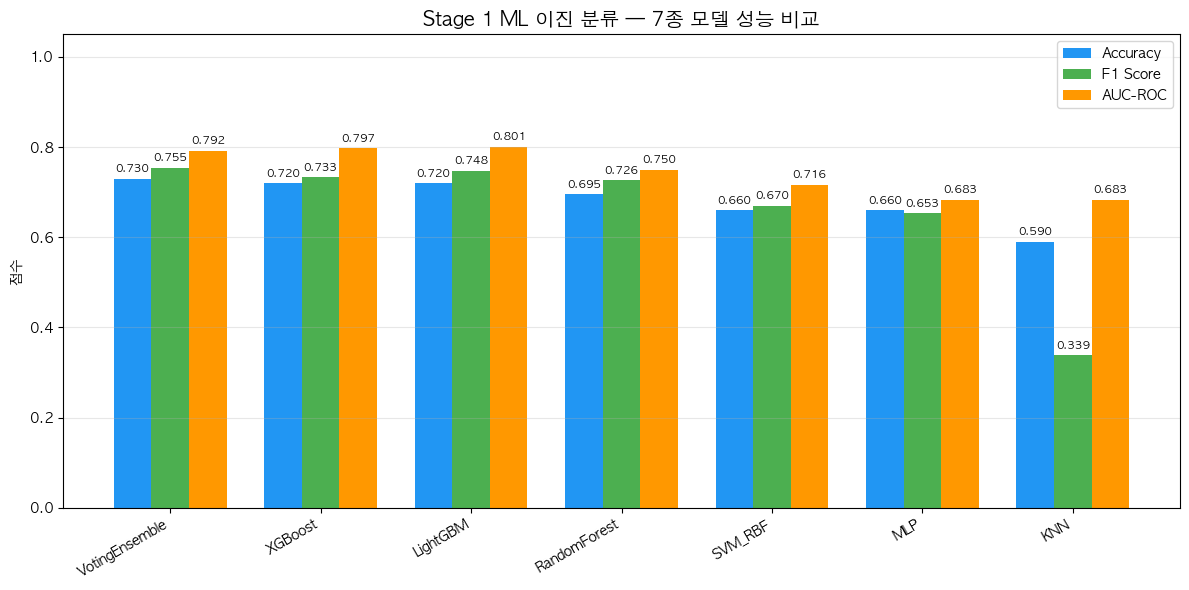

In [7]:
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# 모델 성능 비교 바 차트
names = list(results.keys())
accs = [results[n]['accuracy'] for n in names]
f1s = [results[n]['f1_score'] for n in names]
aucs = [results[n]['auc_roc'] for n in names]

# 정렬
order = sorted(range(len(accs)), key=lambda i: accs[i], reverse=True)
names = [names[i] for i in order]
accs = [accs[i] for i in order]
f1s = [f1s[i] for i in order]
aucs = [aucs[i] for i in order]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(names))
w = 0.25
bars1 = ax.bar(x - w, accs, w, label='Accuracy', color='#2196F3')
bars2 = ax.bar(x, f1s, w, label='F1 Score', color='#4CAF50')
bars3 = ax.bar(x + w, aucs, w, label='AUC-ROC', color='#FF9800')

ax.set_ylabel('점수')
ax.set_title('Stage 1 ML 이진 분류 — 7종 모델 성능 비교', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.3f}', 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/figures/severstal/07_binary_ml_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

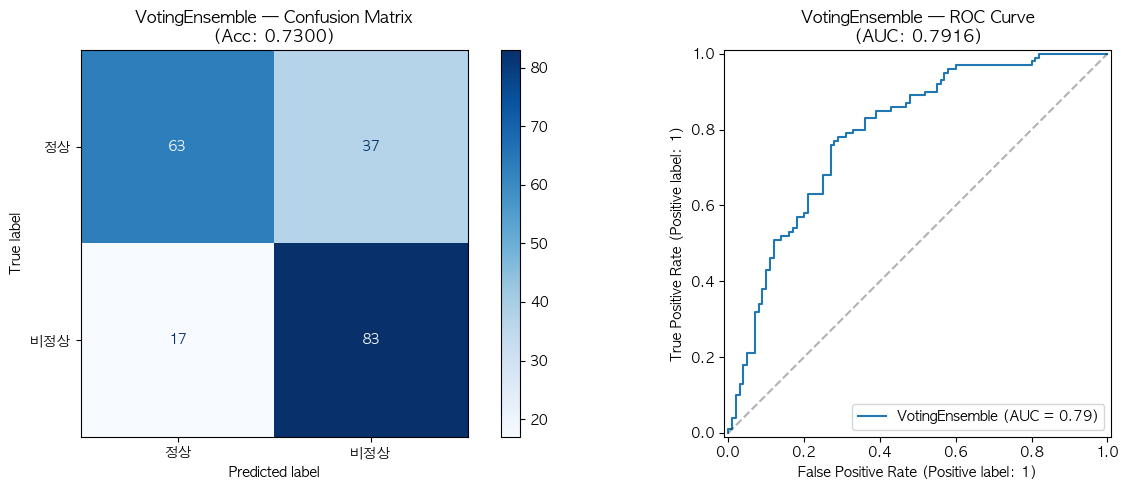


최고 성능 모델: VotingEnsemble
              precision    recall  f1-score   support

          정상       0.79      0.63      0.70       100
         비정상       0.69      0.83      0.75       100

    accuracy                           0.73       200
   macro avg       0.74      0.73      0.73       200
weighted avg       0.74      0.73      0.73       200



In [8]:
# Best 모델(LightGBM) Confusion Matrix + ROC Curve
best_name = max(results, key=lambda k: results[k]['accuracy'])
best = results[best_name]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = best['confusion_matrix']
disp = ConfusionMatrixDisplay(cm, display_labels=['정상', '비정상'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'{best_name} — Confusion Matrix\n(Acc: {best["accuracy"]:.4f})', fontweight='bold')

# ROC Curve
if best['y_prob'] is not None:
    RocCurveDisplay.from_predictions(y_test, best['y_prob'], ax=axes[1], name=best_name)
    axes[1].set_title(f'{best_name} — ROC Curve\n(AUC: {best["auc_roc"]:.4f})', fontweight='bold')
    axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/severstal/07_best_cm_roc.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n최고 성능 모델: {best_name}')
print(best['classification_report'])

## 5. 결론

- **VotingEnsemble**이 Accuracy 73.00%, AUC-ROC 0.7916으로 최고 성능 달성
- Gradient Boosting 계열(XGBoost 72.00%, LightGBM 72.00%)과 VotingEnsemble(73.00%)이 상위권
- 전통 ML만으로는 ~73% 수준이 한계 → **DL 적용 필요성 확인**
- Recall 83.00%: 비정상 이미지의 약 17%를 정상으로 오분류 → 산업 현장에서는 위험